In [1]:
!pip install tensorflow pillow numpy matplotlib scikit-learn seaborn

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 byte


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow:", tf.__version__)
print("GPU:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.21.0
GPU: False


In [3]:
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 8
SEED       = 42

DATASET_DIR = "dataset"
TRAIN_DIR   = os.path.join(DATASET_DIR, "train")
TEST_DIR    = os.path.join(DATASET_DIR, "test")

CLASSES = ["Tshirt", "Shirt", "Jeans", "Dress", "Jacket"]
IMAGES_PER_CLASS_TRAIN = 60
IMAGES_PER_CLASS_TEST  = 15

random.seed(SEED)
np.random.seed(SEED)

In [4]:
CLASS_COLORS = {
    "Tshirt": (60, 120, 200),
    "Shirt":  (200, 200, 60),
    "Jeans":  (30, 60, 130),
    "Dress":  (200, 80, 140),
    "Jacket": (80, 80, 80),
}

In [5]:
def make_synthetic_image(cls, size=(IMG_SIZE, IMG_SIZE)):
    base = CLASS_COLORS[cls]
    noise = np.random.randint(-25, 25, 3)
    color = tuple(int(np.clip(c + n, 0, 255)) for c, n in zip(base, noise))
    img = Image.new("RGB", size, color=color)
    draw = ImageDraw.Draw(img)
    for _ in range(6):
        x1, y1 = np.random.randint(0, size[0]), np.random.randint(0, size[1])
        x2, y2 = np.random.randint(0, size[0]), np.random.randint(0, size[1])
        shape_color = tuple(int(np.clip(c + np.random.randint(-40, 40), 0, 255)) for c in color)
        draw.rectangle([min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)],
                       outline=shape_color, width=2)
    return img

In [6]:
def build_dataset():
    if os.path.exists(DATASET_DIR):
        print(f"Removing existing '{DATASET_DIR}/' ...")
        shutil.rmtree(DATASET_DIR)

    for split, count in [("train", IMAGES_PER_CLASS_TRAIN),
                         ("test", IMAGES_PER_CLASS_TEST)]:
        for cls in CLASSES:
            folder = os.path.join(DATASET_DIR, split, cls)
            os.makedirs(folder, exist_ok=True)
            for i in range(count):
                img = make_synthetic_image(cls)
                img.save(os.path.join(folder, f"{cls}_{i:03d}.jpg"))

    print("\n✅ Dataset created at:", os.path.abspath(DATASET_DIR))

build_dataset()


✅ Dataset created at: c:\Users\Kavana M R\OneDrive\Desktop\python basics\project\dataset


In [7]:
for split in ["train", "test"]:
    print(f"\n--- {split}/ ---")
    split_path = os.path.join(DATASET_DIR, split)
    for cls in sorted(os.listdir(split_path)):
        n = len(os.listdir(os.path.join(split_path, cls)))
        print(f"  {cls}: {n} images")


--- train/ ---
  Dress: 60 images
  Jacket: 60 images
  Jeans: 60 images
  Shirt: 60 images
  Tshirt: 60 images

--- test/ ---
  Dress: 15 images
  Jacket: 15 images
  Jeans: 15 images
  Shirt: 15 images
  Tshirt: 15 images


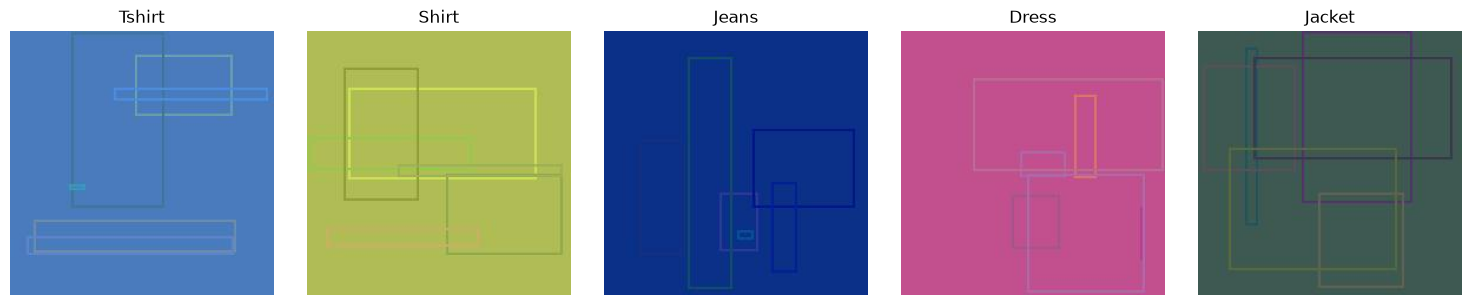

In [8]:
fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 3))
for ax, cls in zip(axes, CLASSES):
    folder = os.path.join(TRAIN_DIR, cls)
    fname = sorted(os.listdir(folder))[0]
    ax.imshow(Image.open(os.path.join(folder, fname)))
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [10]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 300 images belonging to 5 classes.
Found 75 images belonging to 5 classes.


In [11]:
NUM_CLASSES = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)
print("Num classes:", NUM_CLASSES)
print("Train samples:", train_gen.samples)
print("Test samples:", test_gen.samples)

Classes: ['Dress', 'Jacket', 'Jeans', 'Shirt', 'Tshirt']
Num classes: 5
Train samples: 300
Test samples: 75


In [12]:
base = MobileNetV2(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


In [13]:
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.keras',
                    monitor='val_accuracy', save_best_only=True)
]

In [15]:
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.2467 - loss: 1.7656 - val_accuracy: 0.1600 - val_loss: 1.7059
Epoch 2/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 823ms/step - accuracy: 0.3233 - loss: 1.5991 - val_accuracy: 0.2133 - val_loss: 1.7499
Epoch 3/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 909ms/step - accuracy: 0.3633 - loss: 1.4952 - val_accuracy: 0.2267 - val_loss: 1.5689
Epoch 4/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 787ms/step - accuracy: 0.4167 - loss: 1.4351 - val_accuracy: 0.2933 - val_loss: 1.5073
Epoch 5/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 733ms/step - accuracy: 0.3667 - loss: 1.4086 - val_accuracy: 0.2933 - val_loss: 1.4930
Epoch 6/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 772ms/step - accuracy: 0.4533 - loss: 1.3270 - val_accuracy: 0.3067 - val_loss: 1.4572
Epoch 7/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 916ms/step - accuracy: 0.4433 - loss: 1.2952 - val_accuracy: 0.3733 - val_loss: 1.4471
Epoch 8/8
10/10 ━━━━━━━━━━━━━━━━━━━━ 7s 785ms/step - accuracy: 0.4733 - loss: 1.2489 - val_accuracy: 0.3067 - val

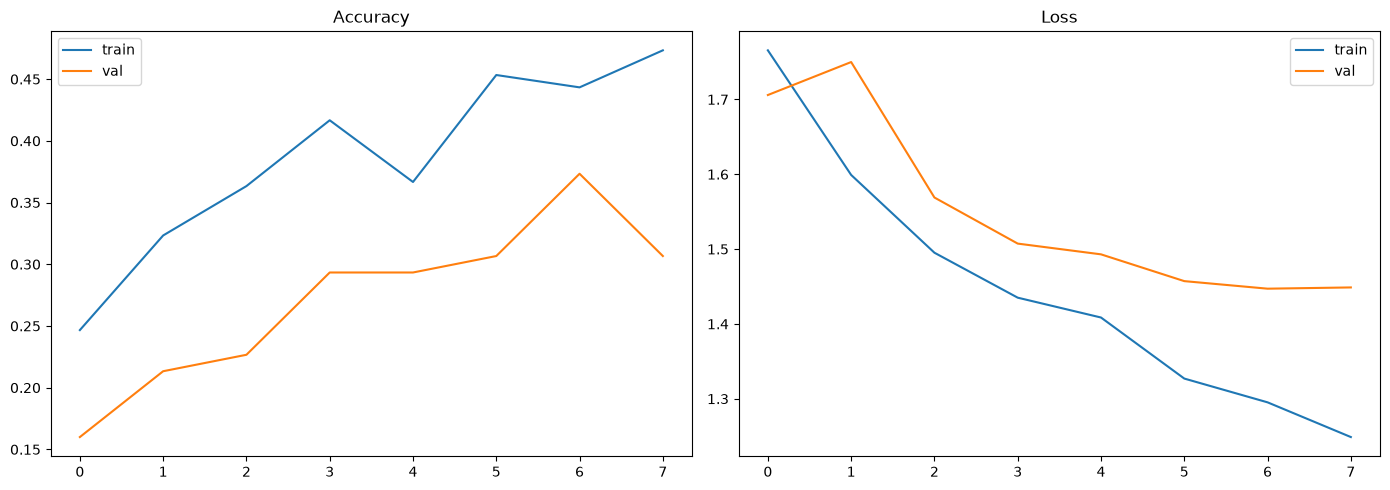

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step - accuracy: 0.3733 - loss: 1.4471

Test Accuracy: 37.33%
Test Loss: 1.4471


In [18]:
test_gen.reset()
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 745ms/step


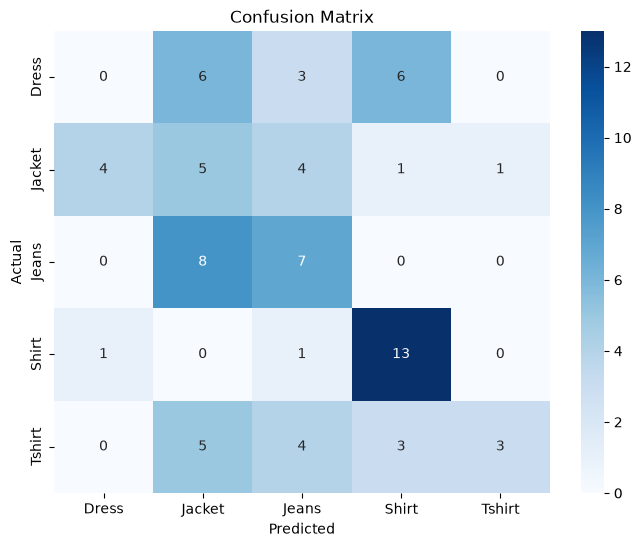

              precision    recall  f1-score   support

       Dress       0.00      0.00      0.00        15
      Jacket       0.21      0.33      0.26        15
       Jeans       0.37      0.47      0.41        15
       Shirt       0.57      0.87      0.68        15
      Tshirt       0.75      0.20      0.32        15

    accuracy                           0.37        75
   macro avg       0.38      0.37      0.33        75
weighted avg       0.38      0.37      0.33        75



In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


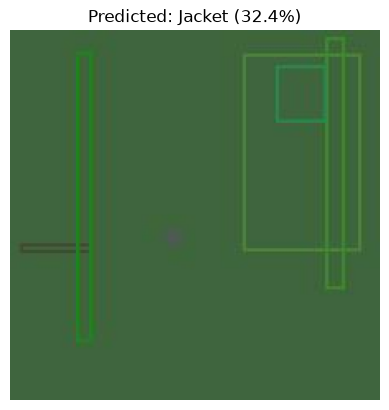

Top 3:
  Jacket: 32.44%
  Dress: 26.21%
  Jeans: 23.52%


In [20]:
import glob

sample_path = random.choice(glob.glob(os.path.join(TEST_DIR, "*", "*.jpg")))
img = Image.open(sample_path).convert('RGB')
arr = np.array(img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
arr = np.expand_dims(arr, axis=0)

pred = model.predict(arr)[0]
top = np.argmax(pred)

plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {class_names[top]} ({pred[top]*100:.1f}%)")
plt.show()

print("Top 3:")
for i in np.argsort(pred)[::-1][:3]:
    print(f"  {class_names[i]}: {pred[i]*100:.2f}%")

In [21]:
model.save('cloth_classifier.keras')
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

print("✅ Saved cloth_classifier.keras")
print("✅ Saved class_names.json")
print("Class order:", class_names)

✅ Saved cloth_classifier.keras
✅ Saved class_names.json
Class order: ['Dress', 'Jacket', 'Jeans', 'Shirt', 'Tshirt']


In [22]:
# from google.colab import files
# files.download('cloth_classifier.keras')
# files.download('class_names.json')